In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KernelDensity

In [81]:
df=pd.read_csv("Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [82]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [83]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [84]:
df.shape

(891, 12)

In [85]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [86]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [87]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [88]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

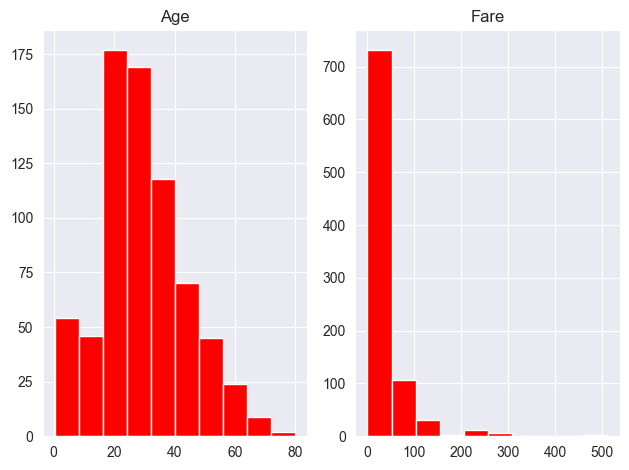

In [89]:
select_dtyps=df.select_dtypes(['float'])
select_dtyps.hist(color="red")
plt.tight_layout()
plt.show()

In [90]:
df.select_dtypes('float').columns

Index(['Age', 'Fare'], dtype='object')

In [91]:
for i in['Fare','Age']:
    df[i]=df[i].fillna(df[i].median())

In [92]:
df.select_dtypes('object').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [93]:
for x in ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']:
    df[x]=df[x].fillna(df[x].mode()[0])

In [94]:
df.duplicated().sum()

np.int64(0)

In [95]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

<Axes: >

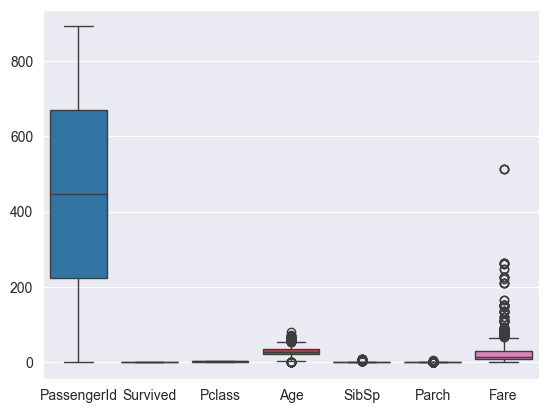

In [96]:
x=['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
sns.boxplot(data=df[x])

outlier 1

In [97]:
# q1=np.percentile(df['Fare'],25,method="midpoint")
# q3=np.percentile(df['Fare'],75,method="midpoint")
# print(q1)
# print(q3)

In [98]:
# iqr=q3-q1
# iqr

In [99]:
# upper=q3+1.5*iqr
# lower=q1-1.5*iqr
# print(upper)
# print(lower)

In [100]:
# outliers=[]
# for i in df['Fare']:
#     if((i>upper) or (i<lower)):
#       outliers.append(i)
# print(outliers)

In [101]:
# df1=(df['Fare']>upper)  | (df['Fare']<lower)

In [102]:
# z = df.loc[df1]

In [103]:
# df.drop(z.index, inplace=True)

In [104]:
# df.shape

In [105]:
# outliers=[]
# for i in df['Fare']:
#     if((i>upper) or (i<lower)):
#       outliers.append(i)
# outliers

outlier 2

In [106]:
# q1=np.percentile(df['Parch'],25,method="midpoint")
# q3=np.percentile(df["Parch"],75,method="midpoint")
# print(q1)
# print(q3)

In [107]:
# iqr=q3-q1
# iqr

In [108]:
# upper=q3+1.5*iqr
# lower=q1-1.5*iqr
# print(upper)
# print(lower)

In [109]:
# outliers=[]
# for i in df['Parch']:
#     if((i>upper) or (i<lower)):
#       outliers.append(i)
# print(outliers)

In [110]:
# df1=(df['Parch']>upper)  | (df['Parch']<lower)

In [111]:
# z = df.loc[df1]
# df.drop(z.index, inplace=True)

In [112]:
# df.shape

outlier 3

In [113]:
# q1=np.percentile(df["Age"],25,method="midpoint")
# q3=np.percentile(df["Age"],75,method="midpoint")
# print(q1)
# print(q3)

In [114]:
# iqr=q3-q1
# iqr

In [115]:
# upper=q3+1.5*iqr
# print(upper)
# lower=q1-1.5*iqr
# print(lower)

In [116]:
# outliers=[]
# for i in df['Age']:
#     if((i>upper) or (i<lower)):
#         outliers.append(i)
# print(outliers)


In [117]:
# df1=(df['Age']>upper) | (df['Age']<lower)

In [118]:
# z=df.loc[df1]

In [119]:
# df.drop(z.index,inplace=True)

In [120]:
# df.shape

outlier 4

In [121]:
# q1=np.percentile(df["SibSp"],25,method="midpoint")
# q3=np.percentile(df["SibSp"],75,method="midpoint")
# print(q1)
# print(q3)

In [122]:
# iqr=q3-q1
# iqr

In [123]:
# upper=q3+1.5*iqr
# print(upper)
# lower=q1-1.5*iqr
# print(lower)

In [124]:
# outliers=[]
# for i in df['SibSp']:
#     if(i<lower) or (i>upper):
#         outliers.append(i)
# print(outliers)

In [125]:
# df1=(df['SibSp']<lower) | (df["SibSp"]>upper)

In [126]:
# z=df.loc[df1]

In [127]:
# df.drop(z.index,inplace=True)

In [128]:
# df.shape

encoding

In [129]:
x=df.select_dtypes(['object']).columns
x

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [130]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [131]:
df.drop(['Name','PassengerId'],axis=1,inplace=True)

In [132]:
from  sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [133]:
for i in ['Sex', 'Ticket', 'Cabin', 'Embarked']:
    df[i]=le.fit_transform(df[i])
df[i]

0      2
1      0
2      2
3      2
4      2
      ..
886    2
887    2
888    2
889    0
890    1
Name: Embarked, Length: 891, dtype: int64

In [134]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,523,7.2500,47,2
1,1,1,0,38.0,1,0,596,71.2833,81,0
2,1,3,0,26.0,0,0,669,7.9250,47,2
3,1,1,0,35.0,1,0,49,53.1000,55,2
4,0,3,1,35.0,0,0,472,8.0500,47,2
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,101,13.0000,47,2
887,1,1,0,19.0,0,0,14,30.0000,30,2
888,0,3,0,28.0,1,2,675,23.4500,47,2
889,1,1,1,26.0,0,0,8,30.0000,60,0


scaling

In [135]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')

In [136]:
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler()

In [137]:
for i in [['Pclass', 'Age', 'SibSp','Parch', 'Fare']]:
    df[i]=mm.fit_transform(df[i])
df[i]


,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.271174,0.125,0.000000,0.014151
1,0.0,0.472229,0.125,0.000000,0.139136
2,1.0,0.321438,0.000,0.000000,0.015469
3,0.0,0.434531,0.125,0.000000,0.103644
4,1.0,0.434531,0.000,0.000000,0.015713
...,...,...,...,...,...
886,0.5,0.334004,0.000,0.000000,0.025374
887,0.0,0.233476,0.000,0.000000,0.058556
888,1.0,0.346569,0.125,0.333333,0.045771
889,0.0,0.321438,0.000,0.000000,0.058556


In [138]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,0.654321,0.647587,0.363679,0.065376,0.063599,338.528620,0.062858,53.639731,1.536476
std,0.486592,0.418036,0.477990,0.163605,0.137843,0.134343,200.850657,0.096995,23.568293,0.791503
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.271174,0.000000,0.000000,158.500000,0.015440,47.000000,1.000000
50%,0.000000,1.000000,1.000000,0.346569,0.000000,0.000000,337.000000,0.028213,47.000000,2.000000
75%,1.000000,1.000000,1.000000,0.434531,0.125000,0.000000,519.500000,0.060508,47.000000,2.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,680.000000,1.000000,146.000000,2.000000


In [139]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1.0,1,0.271174,0.125,0.000000,523,0.014151,47,2
1,1,0.0,0,0.472229,0.125,0.000000,596,0.139136,81,0
2,1,1.0,0,0.321438,0.000,0.000000,669,0.015469,47,2
3,1,0.0,0,0.434531,0.125,0.000000,49,0.103644,55,2
4,0,1.0,1,0.434531,0.000,0.000000,472,0.015713,47,2
...,...,...,...,...,...,...,...,...,...,...
886,0,0.5,1,0.334004,0.000,0.000000,101,0.025374,47,2
887,1,0.0,0,0.233476,0.000,0.000000,14,0.058556,30,2
888,0,1.0,0,0.346569,0.125,0.333333,675,0.045771,47,2
889,1,0.0,1,0.321438,0.000,0.000000,8,0.058556,60,0


random forest

In [140]:
x=df.drop(['Survived'],axis=1)

In [141]:
y=df["Survived"]

In [142]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=25)

In [143]:
from sklearn.ensemble import RandomForestClassifier
rndm=RandomForestClassifier(random_state=42,n_estimators=100,bootstrap=True,oob_score=True)

In [144]:
model=rndm.fit(x_train,y_train)

In [145]:
y_pred=model.predict(x_test)

In [146]:
y_test

709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
137    0
696    0
485    0
244    0
344    0
853    1
621    1
653    1
886    0
110    0
294    0
447    1
192    1
682    0
538    0
Name: Survived, dtype: int64

In [147]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred),confusion_matrix(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.81      1.00      0.90        13
           1       1.00      0.75      0.86        12

    accuracy                           0.88        25
   macro avg       0.91      0.88      0.88        25
weighted avg       0.90      0.88      0.88        25
 [[13  0]
 [ 3  9]]


bernouli

In [148]:
from sklearn.naive_bayes import BernoulliNB
brnl=BernoulliNB()

In [149]:
model=brnl.fit(x_train,y_train)

In [150]:
y1_pred=model.predict(x_test)

In [151]:
y_test

709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
137    0
696    0
485    0
244    0
344    0
853    1
621    1
653    1
886    0
110    0
294    0
447    1
192    1
682    0
538    0
Name: Survived, dtype: int64

In [152]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y1_pred),confusion_matrix(y_test,y1_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.90      0.75      0.82        12

    accuracy                           0.84        25
   macro avg       0.85      0.84      0.84        25
weighted avg       0.85      0.84      0.84        25
 [[12  1]
 [ 3  9]]


ada boost


In [153]:
from sklearn.ensemble import AdaBoostClassifier
adab=AdaBoostClassifier()

In [154]:
model = adab.fit(x_train, y_train)

In [155]:
y2_pred = model.predict(x_test)

In [156]:
y_test

709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
137    0
696    0
485    0
244    0
344    0
853    1
621    1
653    1
886    0
110    0
294    0
447    1
192    1
682    0
538    0
Name: Survived, dtype: int64

In [157]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y2_pred),confusion_matrix(y_test,y2_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        13
           1       1.00      0.83      0.91        12

    accuracy                           0.92        25
   macro avg       0.93      0.92      0.92        25
weighted avg       0.93      0.92      0.92        25
 [[13  0]
 [ 2 10]]


ROC Curve

AUC_SCORE 0.9743589743589743


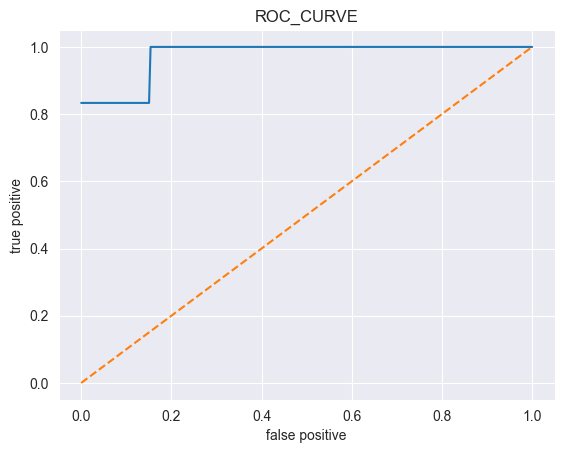

In [158]:
from sklearn.metrics import roc_curve,roc_auc_score
y_prob=rndm.predict_proba(x_test)[:,1]
fpr,tpr,thresholds =roc_curve(y_test,y_prob)
auc_score=roc_auc_score(y_test,y_prob)
print("AUC_SCORE",auc_score)

fpr_smooth=np.linspace(0, 1, 300)
tpr_smooth=np.interp(fpr_smooth,fpr,tpr)
plt.plot(fpr_smooth,tpr_smooth,label="ROC CURVE (AUC=%0.2F)" % auc_score)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("false positive")
plt.ylabel("true positive")
plt.title("ROC_CURVE")
plt.show()